# Hierarchical Clustering: Agglomerative and Divisive

- **Agglomerative (bottom-up):** every point starts as its own cluster; repeatedly merge the two closest clusters.
- **Divisive (top-down):** all points start in one cluster; repeatedly split the cluster with the largest diameter.

Requires only `numpy` and `matplotlib`:  `pip install numpy matplotlib`

## 1. Imports and sample data

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# 12 points in 3 natural groups
X = np.array([
    [1.0, 1.0], [1.5, 2.0], [2.0, 1.5], [1.2, 1.8],      # group A
    [8.0, 8.0], [8.5, 9.0], [9.0, 8.5], [8.2, 8.8],      # group B
    [1.0, 9.0], [1.5, 8.5], [2.0, 9.5], [1.3, 9.2],      # group C
])
K = 3  # number of clusters we want at the end

## 2. Distance functions

In [9]:
def dist(a, b):
    """Euclidean distance between two points."""
    return np.sqrt(np.sum((a - b) ** 2))


def cluster_distance(c1, c2):
    """Average linkage: mean distance between all pairs of points."""
    return np.mean([dist(X[i], X[j]) for i in c1 for j in c2])

## 3. Agglomerative clustering (bottom-up)

1. Start with each point as its own cluster.
2. Find the two closest clusters and merge them.
3. Repeat until only `K` clusters remain.

In [10]:
def agglomerative(k):
    clusters = [[i] for i in range(len(X))]
    step = 1
    while len(clusters) > k:
        best = None
        for a in range(len(clusters)):
            for b in range(a + 1, len(clusters)):
                d = cluster_distance(clusters[a], clusters[b])
                if best is None or d < best[0]:
                    best = (d, a, b)
        d, a, b = best
        print(f"Step {step}: merge {clusters[a]} + {clusters[b]}  (distance = {d:.2f})")
        clusters[a] = clusters[a] + clusters[b]
        clusters.pop(b)
        step += 1
    return clusters

## 4. Divisive clustering (top-down, DIANA)

1. Start with all points in one cluster.
2. Pick the cluster with the largest diameter.
3. Split it: the point farthest from the others starts a new group, and points closer to the new group than to the old one move over.
4. Repeat until there are `K` clusters.

In [11]:
def diameter(c):
    if len(c) < 2:
        return 0
    return max(dist(X[i], X[j]) for i in c for j in c)


def split(c):
    c = list(c)
    # point with the largest average distance to the rest starts the new group
    avg = [np.mean([dist(X[i], X[j]) for j in c if j != i]) for i in c]
    new_group = [c[int(np.argmax(avg))]]
    old_group = [i for i in c if i != new_group[0]]

    moved = True
    while moved and len(old_group) > 1:
        moved = False
        for p in old_group:
            d_old = np.mean([dist(X[p], X[j]) for j in old_group if j != p])
            d_new = np.mean([dist(X[p], X[j]) for j in new_group])
            if d_new < d_old:
                old_group.remove(p)
                new_group.append(p)
                moved = True
                break
    return old_group, new_group


def divisive(k):
    clusters = [list(range(len(X)))]
    step = 1
    while len(clusters) < k:
        target = max(clusters, key=diameter)
        a, b = split(target)
        print(f"Step {step}: split {sorted(target)} -> {sorted(a)} and {sorted(b)}")
        clusters.remove(target)
        clusters += [a, b]
        step += 1
    return clusters

## 5. Run agglomerative

In [12]:
agg_clusters = agglomerative(K)
print("\nFinal clusters:", [sorted(c) for c in agg_clusters])

Step 1: merge [8] + [11]  (distance = 0.36)
Step 2: merge [1] + [3]  (distance = 0.36)
Step 3: merge [5] + [7]  (distance = 0.36)
Step 4: merge [8, 11] + [9]  (distance = 0.72)
Step 5: merge [1, 3] + [2]  (distance = 0.78)
Step 6: merge [5, 7] + [6]  (distance = 0.78)
Step 7: merge [8, 11, 9] + [10]  (distance = 1.00)
Step 8: merge [0] + [1, 3, 2]  (distance = 1.02)
Step 9: merge [4] + [5, 7, 6]  (distance = 1.02)

Final clusters: [[0, 1, 2, 3], [4, 5, 6, 7], [8, 9, 10, 11]]


## 6. Run divisive

In [13]:
div_clusters = divisive(K)
print("\nFinal clusters:", [sorted(c) for c in div_clusters])

Step 1: split [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11] -> [4, 5, 6, 7, 8, 9, 10, 11] and [0, 1, 2, 3]
Step 2: split [4, 5, 6, 7, 8, 9, 10, 11] -> [8, 9, 10, 11] and [4, 5, 6, 7]

Final clusters: [[0, 1, 2, 3], [8, 9, 10, 11], [4, 5, 6, 7]]


## 7. Visualize both results

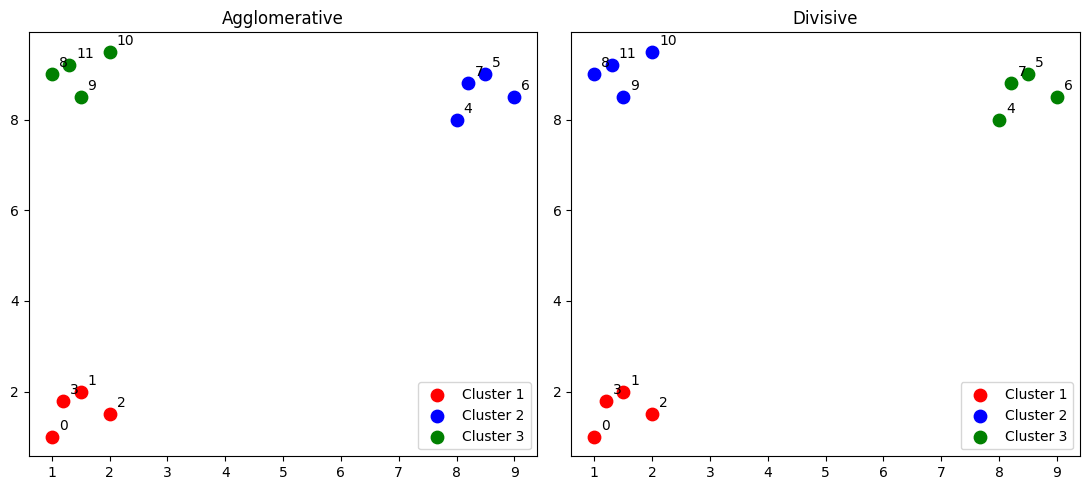

In [14]:
def plot(ax, clusters, title):
    colors = ["red", "blue", "green", "orange", "purple"]
    for n, c in enumerate(clusters):
        pts = X[c]
        ax.scatter(pts[:, 0], pts[:, 1], color=colors[n % 5], s=80, label=f"Cluster {n + 1}")
    for i, (x, y) in enumerate(X):
        ax.annotate(str(i), (x, y), textcoords="offset points", xytext=(5, 5))
    ax.set_title(title)
    ax.legend()


fig, axes = plt.subplots(1, 2, figsize=(11, 5))
plot(axes[0], agg_clusters, "Agglomerative")
plot(axes[1], div_clusters, "Divisive")
plt.tight_layout()
plt.show()